# Generative Modeling on ArtBench-10: A Comparative Study of VAE, DCGAN, and DDPM

**Course**: Generative AI — 2025/2026, 2nd Semester

**Authors**: João Fernandes e David Ferreira

In [2]:
from __future__ import annotations
import sys
import csv
import math
import random
from pathlib import Path
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchvision import transforms as T
from torchvision.utils import make_grid, save_image
from torchvision.models import inception_v3
import matplotlib.pyplot as plt
from scipy import linalg

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


In [4]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Relative paths (run this notebook from student_start_pack/)
PROJECT_ROOT = Path('..')
SCRIPTS_DIR = PROJECT_ROOT / 'scripts'
KAGGLE_ROOT = PROJECT_ROOT / 'ArtBench-10'

if not KAGGLE_ROOT.exists() or not (SCRIPTS_DIR / 'artbench_local_dataset.py').exists():
    raise FileNotFoundError(
        'Could not resolve project folders from relative paths. '
        'Run this notebook from student_start_pack/ or adjust PROJECT_ROOT.'
    )

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

print('PROJECT_ROOT =', PROJECT_ROOT)
print('KAGGLE_ROOT  =', KAGGLE_ROOT)


PROJECT_ROOT = ..
KAGGLE_ROOT  = ../ArtBench-10


In [7]:
# Uses your existing project helper to load ArtBench-10 from local Kaggle-style files
from artbench_local_dataset import load_kaggle_artbench10_splits

hf_ds = load_kaggle_artbench10_splits(KAGGLE_ROOT)
train_hf = hf_ds["train"]

print("Train size:", len(train_hf))
print("Columns   :", train_hf.column_names)

label_feature = train_hf.features["label"]
class_names = list(label_feature.names)
num_classes = len(class_names)
print("Num classes:", num_classes)
print("Class names:", class_names)

Dataset source: kaggle root='../ArtBench-10'
Train size: 50000
Columns   : ['image', 'label']
Num classes: 10
Class names: ['impressionism', 'realism', 'romanticism', 'expressionism', 'baroque', 'post_impressionism', 'art_nouveau', 'surrealism', 'ukiyo_e', 'renaissance']


In [8]:
# Class distribution summary
train_counts = Counter(train_hf["label"])

print("\nTrain class distribution:")
for cid, name in enumerate(class_names):
    print(f"  {cid:2d} | {name:>15s} | {train_counts.get(cid, 0):6d}")


Train class distribution:
   0 |   impressionism |   5000
   1 |         realism |   5000
   2 |     romanticism |   5000
   3 |   expressionism |   5000
   4 |         baroque |   5000
   5 | post_impressionism |   5000
   6 |     art_nouveau |   5000
   7 |      surrealism |   5000
   8 |         ukiyo_e |   5000
   9 |     renaissance |   5000


## 2. Data Loading and Preprocessing

We build PyTorch datasets and dataloaders for both the 20% development subset and the full test split (for evaluation). Images are converted to tensors in [0, 1] range.

In [9]:
IMAGE_SIZE = 32
BATCH_SIZE = 64
NUM_WORKERS = 2

def safe_num_workers(requested: int) -> int:
    if "ipykernel" in sys.modules and int(requested) > 0:
        print("Notebook kernel detected: forcing num_workers=0 for DataLoader stability.")
        return 0
    return int(requested)

EFFECTIVE_NUM_WORKERS = safe_num_workers(NUM_WORKERS)

transform = T.Compose([
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),  # outputs [0,1]
])


class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split
        self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        ex = self.ds[real_idx]
        img = ex["image"]
        y = int(ex["label"])
        x = self.transform(img) if self.transform else img
        return x, y


# --- Test dataset and loader (full test split for evaluation) ---
test_hf = hf_ds["test"]
test_ds = HFDatasetTorch(test_hf, transform=transform)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Test dataset length:", len(test_ds))
print("Test batches       :", len(test_loader))


Notebook kernel detected: forcing num_workers=0 for DataLoader stability.
Test dataset length: 10000
Test batches       : 157


### Load 20% Development Subset

For fast iteration, we use a 20% subset defined in `training_20_percent.csv`.

In [10]:
TRAINING_CSV_PATH = Path('training_20_percent.csv')
INDEX_COLUMN = 'train_id_original'


def load_ids_from_training_csv(csv_path: Path, index_column: str = "train_id_original") -> list[int]:
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(
            f"training.csv not found: {csv_path}\n"
            "Generate it first with scripts/generate_training_csv.py"
        )
    ids = []
    with open(csv_path, 'r', encoding='utf-8', newline='') as f:
        r = csv.DictReader(f)
        if index_column not in (r.fieldnames or []):
            raise ValueError(f"Column {index_column!r} not present in {csv_path}.")
        for row in r:
            v = str(row.get(index_column, "")).strip()
            if v == "":
                continue
            ids.append(int(v))
    if len(ids) == 0:
        raise ValueError(f"No ids found in {csv_path} column {index_column!r}")
    return ids


train_ids_from_csv = load_ids_from_training_csv(TRAINING_CSV_PATH, index_column=INDEX_COLUMN)
print('Loaded subset ids:', len(train_ids_from_csv))

# Build the 20% subset train dataset and loader
train_ds_subset = HFDatasetTorch(train_hf, transform=transform, indices=train_ids_from_csv)
train_loader_subset = DataLoader(
    train_ds_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

# Full train dataset (for final evaluation)
train_ds_full = HFDatasetTorch(train_hf, transform=transform)
train_loader_full = DataLoader(
    train_ds_full,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print(f'Subset train: {len(train_ds_subset)} samples, {len(train_loader_subset)} batches')
print(f'Full   train: {len(train_ds_full)} samples, {len(train_loader_full)} batches')


Loaded subset ids: 10000
Subset train: 10000 samples, 157 batches
Full   train: 50000 samples, 782 batches


### Visualize Training Samples

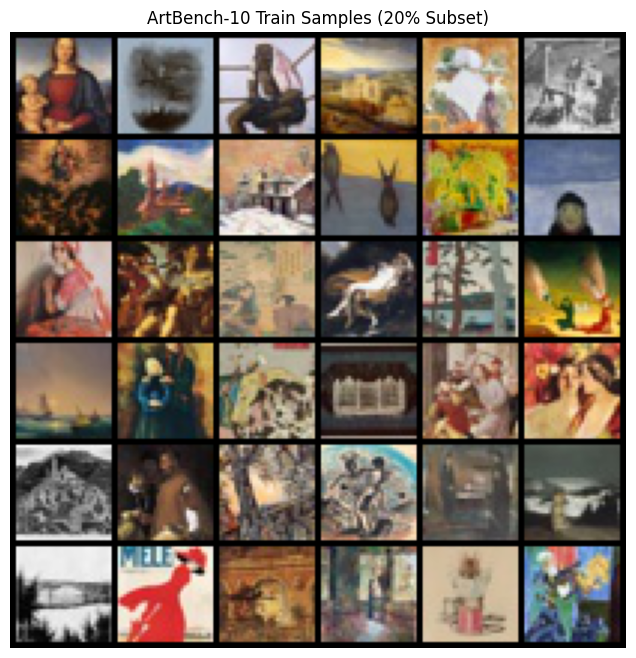

Labels: ['renaissance', 'romanticism', 'expressionism', 'romanticism', 'post_impressionism', 'realism', 'renaissance', 'post_impressionism', 'post_impressionism', 'surrealism', 'post_impressionism', 'expressionism', 'art_nouveau', 'baroque', 'ukiyo_e', 'romanticism', 'ukiyo_e', 'surrealism', 'romanticism', 'post_impressionism', 'ukiyo_e', 'surrealism', 'renaissance', 'art_nouveau', 'realism', 'baroque', 'expressionism', 'surrealism', 'expressionism', 'realism', 'realism', 'art_nouveau', 'impressionism', 'expressionism', 'art_nouveau', 'post_impressionism']


In [11]:
def show_batch_grid(loader, class_names, n_images=36, nrow=6, title='Sample Grid'):
    x, y = next(iter(loader))
    x = x[:n_images]
    y = y[:n_images]

    grid = make_grid(x, nrow=nrow, padding=2)
    np_img = grid.permute(1, 2, 0).cpu().numpy()

    plt.figure(figsize=(8, 8))
    plt.imshow(np_img)
    plt.axis('off')
    plt.title(title)
    plt.show()

    labels_str = [class_names[int(v)] for v in y]
    print('Labels:', labels_str)


show_batch_grid(train_loader_subset, class_names, n_images=36, nrow=6, title='ArtBench-10 Train Samples (20% Subset)')


In [ ]:
def train_epoch_log(epoch, num_epochs, loss_val, extra=""):
    """Print a compact training progress line."""
    print(f"  Epoch [{epoch+1}/{num_epochs}] Loss: {loss_val:.4f} {extra}")


In [ ]:
LATENT_DIM = 128


class VAE(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder: 32x32x3 -> 16x16x64 -> 8x8x128 -> 4x4x256
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Flatten(),
        )
        self.fc_mu = nn.Linear(256 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(256 * 4 * 4, latent_dim)

        # Decoder: z -> 4x4x256 -> 8x8x128 -> 16x16x64 -> 32x32x3
        self.fc_decode = nn.Linear(latent_dim, 256 * 4 * 4)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 4, 2, 1),
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_decode(z).view(-1, 256, 4, 4)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

    @torch.no_grad()
    def sample(self, n, device):
        z = torch.randn(n, self.latent_dim, device=device)
        return self.decode(z)


def vae_loss(recon, x, mu, logvar):
    recon_loss = F.mse_loss(recon, x, reduction='sum') / x.size(0)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recon_loss + kl_loss, recon_loss, kl_loss


vae_model = VAE(LATENT_DIM).to(device)
print(f"VAE parameters: {sum(p.numel() for p in vae_model.parameters()):,}")


VAE parameters: 2,896,003


In [ ]:
VAE_EPOCHS = 50
VAE_LR = 1e-3

vae_optimizer = optim.Adam(vae_model.parameters(), lr=VAE_LR)
vae_losses = []

print("Training VAE...")
for epoch in range(VAE_EPOCHS):
    vae_model.train()
    epoch_loss = 0.0
    for x, _ in train_loader_subset:
        x = x.to(device)
        recon, mu, logvar = vae_model(x)
        loss, recon_l, kl_l = vae_loss(recon, x, mu, logvar)

        vae_optimizer.zero_grad()
        loss.backward()
        vae_optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader_subset)
    vae_losses.append(avg_loss)
    if (epoch + 1) % 1 == 0:
        train_epoch_log(epoch, VAE_EPOCHS, avg_loss)

print("VAE training complete.")


Training VAE...


  Epoch [1/50] Loss: 113.1211 
  Epoch [2/50] Loss: 85.5533 
  Epoch [3/50] Loss: 80.0826 
  Epoch [4/50] Loss: 77.6737 
  Epoch [5/50] Loss: 77.0013 
  Epoch [6/50] Loss: 74.9408 
  Epoch [7/50] Loss: 74.2945 
  Epoch [8/50] Loss: 73.2730 
  Epoch [9/50] Loss: 72.9351 
  Epoch [10/50] Loss: 72.7972 
  Epoch [11/50] Loss: 72.6526 
  Epoch [12/50] Loss: 71.9443 
  Epoch [13/50] Loss: 72.0997 
  Epoch [14/50] Loss: 71.8068 
  Epoch [15/50] Loss: 71.7011 
  Epoch [16/50] Loss: 71.2796 
  Epoch [17/50] Loss: 71.6486 
  Epoch [18/50] Loss: 71.1450 
  Epoch [19/50] Loss: 70.8612 
  Epoch [20/50] Loss: 71.1012 
  Epoch [21/50] Loss: 70.7876 
  Epoch [22/50] Loss: 70.4306 
  Epoch [23/50] Loss: 70.5901 
  Epoch [24/50] Loss: 70.7877 
  Epoch [25/50] Loss: 70.3941 
  Epoch [26/50] Loss: 70.2595 
  Epoch [27/50] Loss: 69.8877 
  Epoch [28/50] Loss: 69.9251 
  Epoch [29/50] Loss: 70.1520 
  Epoch [30/50] Loss: 69.9816 
  Epoch [31/50] Loss: 69.7595 
  Epoch [32/50] Loss: 70.1226 
  Epoch [33/50] 

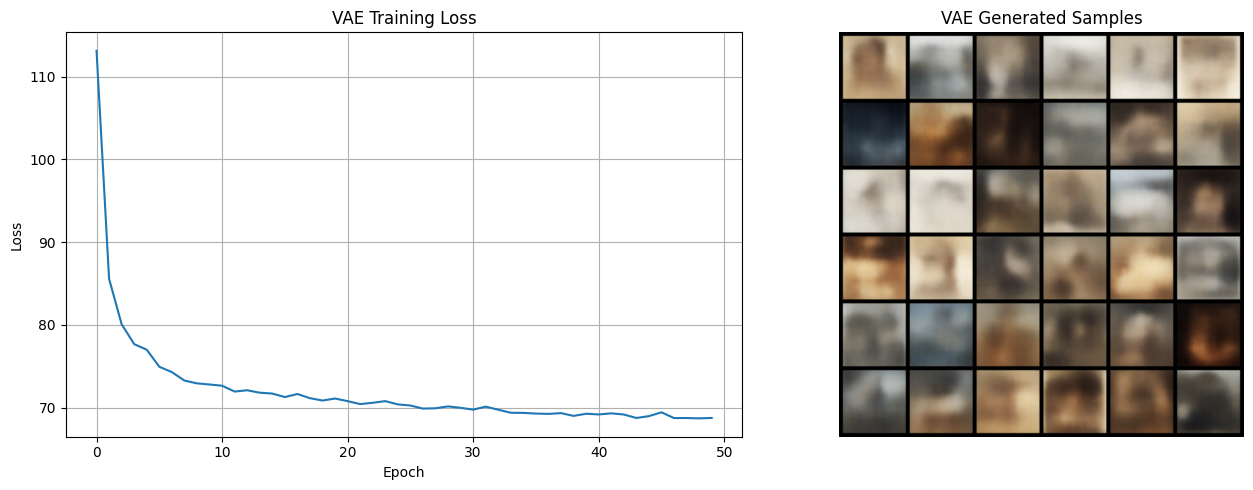

In [15]:
# VAE: Loss curve and generated samples
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(vae_losses)
axes[0].set_title('VAE Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True)

# Generated samples
vae_model.eval()
vae_samples = vae_model.sample(36, device)
grid = make_grid(vae_samples.cpu(), nrow=6, padding=2)
axes[1].imshow(grid.permute(1, 2, 0).numpy())
axes[1].set_title('VAE Generated Samples')
axes[1].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
Z_DIM = 100


def weights_init(m):
    """DCGAN weight initialization from the original paper."""
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


class DCGANGenerator(nn.Module):
    def __init__(self, z_dim=Z_DIM):
        super().__init__()
        self.z_dim = z_dim
        self.main = nn.Sequential(
            # z -> 256 x 4 x 4
            nn.ConvTranspose2d(z_dim, 256, 4, 1, 0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            # -> 128 x 8 x 8
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # -> 64 x 16 x 16
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            # -> 3 x 32 x 32
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.main(z.view(-1, self.z_dim, 1, 1))

    @torch.no_grad()
    def sample(self, n, device):
        z = torch.randn(n, self.z_dim, device=device)
        imgs = self.forward(z)
        return (imgs + 1.0) / 2.0  # Tanh [-1,1] -> [0,1]


class DCGANDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            # 3 x 32 x 32 -> 64 x 16 x 16
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # -> 128 x 8 x 8
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # -> 256 x 4 x 4
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            # -> 1 x 1 x 1
            nn.Conv2d(256, 1, 4, 1, 0, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.main(x).view(-1)


gen_model = DCGANGenerator(Z_DIM).to(device)
disc_model = DCGANDiscriminator().to(device)
gen_model.apply(weights_init)
disc_model.apply(weights_init)

print(f"Generator parameters    : {sum(p.numel() for p in gen_model.parameters()):,}")
print(f"Discriminator parameters: {sum(p.numel() for p in disc_model.parameters()):,}")


Generator parameters    : 1,068,928
Discriminator parameters: 663,296


In [ ]:
GAN_EPOCHS = 50
GAN_LR = 2e-4
GAN_BETA1 = 0.5

criterion_gan = nn.BCELoss()
opt_gen = optim.Adam(gen_model.parameters(), lr=GAN_LR, betas=(GAN_BETA1, 0.999))
opt_disc = optim.Adam(disc_model.parameters(), lr=GAN_LR, betas=(GAN_BETA1, 0.999))

g_losses, d_losses = [], []

print("Training DCGAN...")
for epoch in range(GAN_EPOCHS):
    gen_model.train()
    disc_model.train()
    epoch_g_loss = 0.0
    epoch_d_loss = 0.0

    for x_real, _ in train_loader_subset:
        batch_size = x_real.size(0)
        x_real = x_real.to(device)
        x_real = x_real * 2.0 - 1.0

        real_label = torch.ones(batch_size, device=device)
        fake_label = torch.zeros(batch_size, device=device)

        # --- Train Discriminator ---
        disc_model.zero_grad()
        output_real = disc_model(x_real)
        loss_d_real = criterion_gan(output_real, real_label)

        z = torch.randn(batch_size, Z_DIM, device=device)
        x_fake = gen_model(z)
        output_fake = disc_model(x_fake.detach())
        loss_d_fake = criterion_gan(output_fake, fake_label)

        loss_d = loss_d_real + loss_d_fake
        loss_d.backward()
        opt_disc.step()

        # --- Train Generator ---
        gen_model.zero_grad()
        output_fake2 = disc_model(x_fake)
        loss_g = criterion_gan(output_fake2, real_label)
        loss_g.backward()
        opt_gen.step()

        epoch_g_loss += loss_g.item()
        epoch_d_loss += loss_d.item()

    avg_g = epoch_g_loss / len(train_loader_subset)
    avg_d = epoch_d_loss / len(train_loader_subset)
    g_losses.append(avg_g)
    d_losses.append(avg_d)

    if (epoch + 1) % 1 == 0:
        print(f"  Epoch [{epoch+1}/{GAN_EPOCHS}] D_loss: {avg_d:.4f} G_loss: {avg_g:.4f}")

print("DCGAN training complete.")


Training DCGAN...
  Epoch [1/50] D_loss: 0.2998 G_loss: 5.4526


  Epoch [2/50] D_loss: 0.5327 G_loss: 5.0295
  Epoch [3/50] D_loss: 0.5615 G_loss: 3.5431
  Epoch [4/50] D_loss: 0.5343 G_loss: 4.0728
  Epoch [5/50] D_loss: 0.4092 G_loss: 3.6032
  Epoch [6/50] D_loss: 0.3986 G_loss: 4.2456
  Epoch [7/50] D_loss: 0.6384 G_loss: 3.7208
  Epoch [8/50] D_loss: 0.6015 G_loss: 3.4273
  Epoch [9/50] D_loss: 0.6041 G_loss: 3.4503
  Epoch [10/50] D_loss: 0.6384 G_loss: 3.2545
  Epoch [11/50] D_loss: 0.5622 G_loss: 3.1414
  Epoch [12/50] D_loss: 0.6136 G_loss: 2.9432
  Epoch [13/50] D_loss: 0.5857 G_loss: 3.1354
  Epoch [14/50] D_loss: 0.6652 G_loss: 2.8573
  Epoch [15/50] D_loss: 0.6601 G_loss: 2.8394
  Epoch [16/50] D_loss: 0.6189 G_loss: 2.8609
  Epoch [17/50] D_loss: 0.6013 G_loss: 2.8318
  Epoch [18/50] D_loss: 0.6278 G_loss: 2.7378
  Epoch [19/50] D_loss: 0.6676 G_loss: 2.7137
  Epoch [20/50] D_loss: 0.7866 G_loss: 2.5497
  Epoch [21/50] D_loss: 0.6790 G_loss: 2.6158
  Epoch [22/50] D_loss: 0.7017 G_loss: 2.7063
  Epoch [23/50] D_loss: 0.7805 G_loss: 2.6

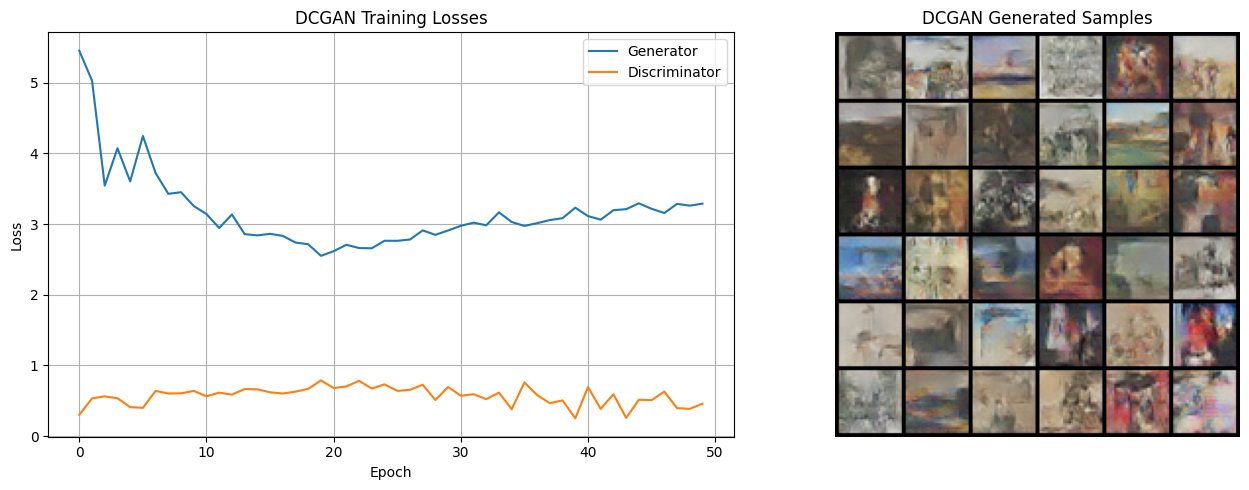

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(g_losses, label='Generator')
axes[0].plot(d_losses, label='Discriminator')
axes[0].set_title('DCGAN Training Losses')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

gen_model.eval()
gan_samples = gen_model.sample(36, device)
grid = make_grid(gan_samples.cpu(), nrow=6, padding=2)
axes[1].imshow(grid.permute(1, 2, 0).numpy())
axes[1].set_title('DCGAN Generated Samples')
axes[1].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
T_STEPS = 1000
BETA_START = 1e-4
BETA_END = 0.02


class DDPMSchedule:
    """Pre-compute all diffusion schedule constants."""
    def __init__(self, T=T_STEPS, beta_start=BETA_START, beta_end=BETA_END, device='cpu'):
        self.T = T
        self.betas = torch.linspace(beta_start, beta_end, T, device=device)
        self.alphas = 1.0 - self.betas
        self.alpha_bar = torch.cumprod(self.alphas, dim=0)
        self.alpha_bar_prev = torch.cat([torch.tensor([1.0], device=device), self.alpha_bar[:-1]])
        self.sqrt_alpha_bar = torch.sqrt(self.alpha_bar)
        self.sqrt_one_minus_alpha_bar = torch.sqrt(1.0 - self.alpha_bar)
        self.sqrt_recip_alpha = torch.sqrt(1.0 / self.alphas)
        self.posterior_variance = self.betas * (1.0 - self.alpha_bar_prev) / (1.0 - self.alpha_bar)

    def q_sample(self, x0, t, noise=None):
        """Forward process: add noise at timestep t."""
        if noise is None:
            noise = torch.randn_like(x0)
        sqrt_ab = self.sqrt_alpha_bar[t].view(-1, 1, 1, 1)
        sqrt_1mab = self.sqrt_one_minus_alpha_bar[t].view(-1, 1, 1, 1)
        return sqrt_ab * x0 + sqrt_1mab * noise, noise


def sinusoidal_embedding(t, dim):
    """Sinusoidal positional encoding for timesteps."""
    half = dim // 2
    freqs = torch.exp(-math.log(10000.0) * torch.arange(half, device=t.device) / half)
    args = t.float().unsqueeze(1) * freqs.unsqueeze(0)
    return torch.cat([torch.cos(args), torch.sin(args)], dim=1)


class ResBlock(nn.Module):
    """Residual block with time embedding injection."""
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        gn_groups_in = min(8, in_ch)
        self.conv1 = nn.Sequential(
            nn.GroupNorm(gn_groups_in, in_ch), nn.SiLU(), nn.Conv2d(in_ch, out_ch, 3, 1, 1)
        )
        self.time_mlp = nn.Sequential(nn.SiLU(), nn.Linear(time_dim, out_ch))
        self.conv2 = nn.Sequential(
            nn.GroupNorm(8, out_ch), nn.SiLU(), nn.Conv2d(out_ch, out_ch, 3, 1, 1)
        )
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(x)
        h = h + self.time_mlp(t_emb).unsqueeze(-1).unsqueeze(-1)
        h = self.conv2(h)
        return h + self.skip(x)


class SimpleUNet(nn.Module):
    """Compact U-Net for 32x32 images with time conditioning."""
    def __init__(self, in_ch=3, base_ch=64, time_dim=256):
        super().__init__()
        self.time_dim = time_dim
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, time_dim), nn.SiLU(), nn.Linear(time_dim, time_dim)
        )

        self.enc1 = ResBlock(in_ch, base_ch, time_dim)         # 32x32
        self.down1 = nn.Conv2d(base_ch, base_ch, 3, 2, 1)       # -> 16x16
        self.enc2 = ResBlock(base_ch, base_ch * 2, time_dim)   # 16x16
        self.down2 = nn.Conv2d(base_ch * 2, base_ch * 2, 3, 2, 1)  # -> 8x8
        self.enc3 = ResBlock(base_ch * 2, base_ch * 4, time_dim)  # 8x8

        self.bot = ResBlock(base_ch * 4, base_ch * 4, time_dim)

        self.up2 = nn.ConvTranspose2d(base_ch * 4, base_ch * 2, 2, 2)  # -> 16x16
        self.dec2 = ResBlock(base_ch * 4, base_ch * 2, time_dim)  # cat with enc2
        self.up1 = nn.ConvTranspose2d(base_ch * 2, base_ch, 2, 2)  # -> 32x32
        self.dec1 = ResBlock(base_ch * 2, base_ch, time_dim)  # cat with enc1

        self.out_conv = nn.Sequential(
            nn.GroupNorm(8, base_ch), nn.SiLU(), nn.Conv2d(base_ch, in_ch, 1)
        )

    def forward(self, x, t):
        t_emb = sinusoidal_embedding(t, self.time_dim)
        t_emb = self.time_mlp(t_emb)

        e1 = self.enc1(x, t_emb)      # 32x32
        e2 = self.enc2(self.down1(e1), t_emb)  # 16x16
        e3 = self.enc3(self.down2(e2), t_emb)  # 8x8

        b = self.bot(e3, t_emb)  # 8x8

        d2 = self.dec2(torch.cat([self.up2(b), e2], dim=1), t_emb)  # 16x16
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1), t_emb)  # 32x32

        return self.out_conv(d1)


schedule = DDPMSchedule(T=T_STEPS, device=device)
ddpm_model = SimpleUNet(in_ch=3, base_ch=64, time_dim=256).to(device)
print(f"DDPM U-Net parameters: {sum(p.numel() for p in ddpm_model.parameters()):,}")


DDPM U-Net parameters: 3,675,849


In [ ]:
DDPM_EPOCHS = 20 
DDPM_LR = 2e-4

ddpm_optimizer = optim.Adam(ddpm_model.parameters(), lr=DDPM_LR)
ddpm_losses = []

print("Training DDPM...")
for epoch in range(DDPM_EPOCHS):
    ddpm_model.train()
    epoch_loss = 0.0

    for x, _ in train_loader_subset:
        x = x.to(device)
        x = x * 2.0 - 1.0

        t = torch.randint(0, T_STEPS, (x.size(0),), device=device)

        x_noisy, noise = schedule.q_sample(x, t)

        noise_pred = ddpm_model(x_noisy, t)
        loss = F.mse_loss(noise_pred, noise)

        ddpm_optimizer.zero_grad()
        loss.backward()
        ddpm_optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader_subset)
    ddpm_losses.append(avg_loss)
    if (epoch + 1) % 1 == 0:
        train_epoch_log(epoch, DDPM_EPOCHS, avg_loss)

print("DDPM training complete.")


Training DDPM...
  Epoch [1/20] Loss: 0.1298 
  Epoch [2/20] Loss: 0.0557 
  Epoch [3/20] Loss: 0.0505 


  Epoch [4/20] Loss: 0.0480 
  Epoch [5/20] Loss: 0.0471 
  Epoch [6/20] Loss: 0.0470 
  Epoch [7/20] Loss: 0.0451 
  Epoch [8/20] Loss: 0.0422 
  Epoch [9/20] Loss: 0.0429 
  Epoch [10/20] Loss: 0.0429 
  Epoch [11/20] Loss: 0.0412 
  Epoch [12/20] Loss: 0.0428 
  Epoch [13/20] Loss: 0.0400 
  Epoch [14/20] Loss: 0.0398 
  Epoch [15/20] Loss: 0.0406 
  Epoch [16/20] Loss: 0.0408 
  Epoch [17/20] Loss: 0.0389 
  Epoch [18/20] Loss: 0.0393 
  Epoch [19/20] Loss: 0.0386 
  Epoch [20/20] Loss: 0.0394 
DDPM training complete.


Generating DDPM samples (this may take a moment)...


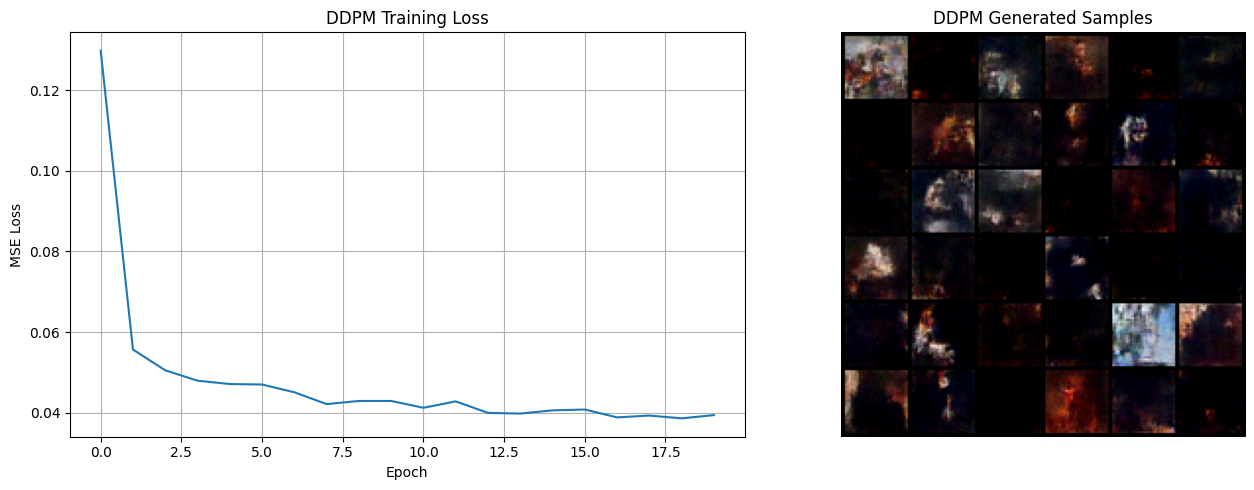

DDPM sampling complete.


In [ ]:
@torch.no_grad()
def ddpm_sample(model, schedule, n_samples, img_shape=(3, 32, 32), device='cpu'):
    """Generate samples by iteratively denoising from pure noise."""
    model.eval()
    x = torch.randn(n_samples, *img_shape, device=device)

    for t_val in reversed(range(schedule.T)):
        t_batch = torch.full((n_samples,), t_val, device=device, dtype=torch.long)
        noise_pred = model(x, t_batch)

        beta_t = schedule.betas[t_val]
        sqrt_recip_alpha_t = schedule.sqrt_recip_alpha[t_val]
        sqrt_1mab_t = schedule.sqrt_one_minus_alpha_bar[t_val]

        x = sqrt_recip_alpha_t * (x - beta_t / sqrt_1mab_t * noise_pred)

        if t_val > 0:
            noise = torch.randn_like(x)
            x = x + torch.sqrt(schedule.posterior_variance[t_val]) * noise

    x = torch.clamp(x, -1.0, 1.0)
    x = (x + 1.0) / 2.0
    return x


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ddpm_losses)
axes[0].set_title('DDPM Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].grid(True)

print("Generating DDPM samples (this may take a moment)...")
ddpm_samples = ddpm_sample(ddpm_model, schedule, 36, device=device)
grid = make_grid(ddpm_samples.cpu(), nrow=6, padding=2)
axes[1].imshow(grid.permute(1, 2, 0).numpy())
axes[1].set_title('DDPM Generated Samples')
axes[1].axis('off')

plt.tight_layout()
plt.show()
print("DDPM sampling complete.")


In [ ]:
class InceptionFeatureExtractor:
    """Extract 2048-dim pool3 features from InceptionV3 for FID/KID."""
    def __init__(self, device):
        self.device = device
        self.model = inception_v3(weights='IMAGENET1K_V1', transform_input=False)
        self.model.fc = nn.Identity()
        self.model.eval()
        self.model.to(device)
        self.resize = T.Resize((299, 299), interpolation=T.InterpolationMode.BILINEAR, antialias=True)
        self.normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    @torch.no_grad()
    def extract_features(self, images_tensor, batch_size=64):
        """Extract features from a (N, 3, H, W) tensor in [0, 1] range."""
        feats = []
        for i in range(0, images_tensor.size(0), batch_size):
            batch = images_tensor[i:i+batch_size].to(self.device)
            batch = self.resize(batch)
            batch = self.normalize(batch)
            f = self.model(batch)
            feats.append(f.cpu())
        return torch.cat(feats, dim=0).numpy()


def compute_fid(feats_real, feats_gen):
    """Compute Fréchet Inception Distance between two feature sets."""
    mu_r = np.mean(feats_real, axis=0)
    mu_g = np.mean(feats_gen, axis=0)
    sigma_r = np.cov(feats_real, rowvar=False)
    sigma_g = np.cov(feats_gen, rowvar=False)

    diff = mu_r - mu_g
    covmean, _ = linalg.sqrtm(sigma_r @ sigma_g, disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = diff @ diff + np.trace(sigma_r + sigma_g - 2.0 * covmean)
    return float(fid)


def compute_kid(feats_real, feats_gen, n_subsets=50, subset_size=100):
    """Compute Kernel Inception Distance (polynomial kernel, degree=3)."""
    n_r = feats_real.shape[0]
    n_g = feats_gen.shape[0]
    kid_values = []

    for _ in range(n_subsets):
        idx_r = np.random.choice(n_r, subset_size, replace=False)
        idx_g = np.random.choice(n_g, subset_size, replace=False)
        fr = feats_real[idx_r]
        fg = feats_gen[idx_g]
        
        d = fr.shape[1]
        krr = (fr @ fr.T / d + 1.0) ** 3
        kgg = (fg @ fg.T / d + 1.0) ** 3
        krg = (fr @ fg.T / d + 1.0) ** 3

        m = subset_size
        kid_val = (np.sum(krr) - np.trace(krr)) / (m * (m - 1)) \
                + (np.sum(kgg) - np.trace(kgg)) / (m * (m - 1)) \
                - 2.0 * np.mean(krg)
        kid_values.append(kid_val)

    return float(np.mean(kid_values)), float(np.std(kid_values))


print("Evaluation functions defined.")
print("Creating InceptionV3 feature extractor...")
feat_extractor = InceptionFeatureExtractor(device)
print("InceptionV3 ready.")


Evaluation functions defined.
Creating InceptionV3 feature extractor...
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /home/zeus/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


  0%|          | 0.00/104M [00:00<?, ?B/s]

100%|██████████| 104M/104M [00:00<00:00, 455MB/s] 


InceptionV3 ready.


In [ ]:
N_EVAL = 5000

def collect_real_images(loader, n=N_EVAL):
    """Collect n real images from a dataloader as a single tensor."""
    imgs = []
    count = 0
    for x, _ in loader:
        imgs.append(x)
        count += x.size(0)
        if count >= n:
            break
    all_imgs = torch.cat(imgs, dim=0)[:n]
    return all_imgs


print(f"Collecting {N_EVAL} real test images...")
real_images = collect_real_images(test_loader, N_EVAL)
print(f"Real images tensor shape: {real_images.shape}")

print("Extracting InceptionV3 features for real images...")
real_features = feat_extractor.extract_features(real_images)
print(f"Real features shape: {real_features.shape}")


Real images tensor shape: torch.Size([5000, 3, 32, 32])
Extracting InceptionV3 features for real images...
Real features shape: (5000, 2048)


In [ ]:
NUM_SEEDS = 10  
GEN_BATCH = 256  


def generate_vae_samples(model, n, seed, device):
    """Generate n VAE samples with a given seed."""
    torch.manual_seed(seed)
    model.eval()
    imgs = []
    remaining = n
    while remaining > 0:
        batch_n = min(GEN_BATCH, remaining)
        z = torch.randn(batch_n, model.latent_dim, device=device)
        batch_imgs = model.decode(z)
        imgs.append(batch_imgs.cpu())
        remaining -= batch_n
    return torch.cat(imgs, dim=0)[:n]


def generate_gan_samples(model, n, seed, device):
    """Generate n GAN samples with a given seed."""
    torch.manual_seed(seed)
    model.eval()
    imgs = []
    remaining = n
    while remaining > 0:
        batch_n = min(GEN_BATCH, remaining)
        z = torch.randn(batch_n, model.z_dim, device=device)
        batch_imgs = model(z)
        batch_imgs = (batch_imgs + 1.0) / 2.0  
        imgs.append(batch_imgs.cpu())
        remaining -= batch_n
    return torch.cat(imgs, dim=0)[:n]


def generate_ddpm_samples(model, schedule, n, seed, device):
    """Generate n DDPM samples with a given seed."""
    torch.manual_seed(seed)
    model.eval()
    imgs = []
    remaining = n
    while remaining > 0:
        batch_n = min(GEN_BATCH, remaining)
        batch_imgs = ddpm_sample(model, schedule, batch_n, device=device)
        imgs.append(batch_imgs.cpu())
        remaining -= batch_n
    return torch.cat(imgs, dim=0)[:n]


def evaluate_model(gen_func, real_features, feat_extractor, seeds, n_eval=N_EVAL):
    """Evaluate a model across multiple seeds, computing FID and KID."""
    fid_scores = []
    kid_means = []
    kid_stds = []

    for i, seed in enumerate(seeds):
        print(f"  Seed {i+1}/{len(seeds)} (seed={seed})...", end=" ")

        gen_images = gen_func(seed)
        gen_images = torch.clamp(gen_images, 0.0, 1.0)

        gen_features = feat_extractor.extract_features(gen_images)

        fid = compute_fid(real_features, gen_features)
        kid_mean, kid_std = compute_kid(real_features, gen_features)

        fid_scores.append(fid)
        kid_means.append(kid_mean)
        kid_stds.append(kid_std)
        print(f"FID={fid:.2f}, KID={kid_mean:.6f}±{kid_std:.6f}")

    return {
        'fid_mean': float(np.mean(fid_scores)),
        'fid_std': float(np.std(fid_scores)),
        'kid_mean': float(np.mean(kid_means)),
        'kid_std': float(np.std(kid_means)),
        'fid_all': fid_scores,
        'kid_all': kid_means,
    }


seeds = list(range(42, 42 + NUM_SEEDS))
print(f"Will evaluate with {NUM_SEEDS} seeds: {seeds}")


Will evaluate with 10 seeds: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]


In [ ]:
# --- VAE Evaluation ---
print("=" * 60)
print("Evaluating VAE...")
print("=" * 60)
vae_results = evaluate_model(
    gen_func=lambda seed: generate_vae_samples(vae_model, N_EVAL, seed, device),
    real_features=real_features,
    feat_extractor=feat_extractor,
    seeds=seeds,
)
print(f"\nVAE FID: {vae_results['fid_mean']:.2f} ± {vae_results['fid_std']:.2f}")
print(f"VAE KID: {vae_results['kid_mean']:.6f} ± {vae_results['kid_std']:.6f}")

# --- DCGAN Evaluation ---
print("\n" + "=" * 60)
print("Evaluating DCGAN...")
print("=" * 60)
dcgan_results = evaluate_model(
    gen_func=lambda seed: generate_gan_samples(gen_model, N_EVAL, seed, device),
    real_features=real_features,
    feat_extractor=feat_extractor,
    seeds=seeds,
)
print(f"\nDCGAN FID: {dcgan_results['fid_mean']:.2f} ± {dcgan_results['fid_std']:.2f}")
print(f"DCGAN KID: {dcgan_results['kid_mean']:.6f} ± {dcgan_results['kid_std']:.6f}")

# --- DDPM Evaluation ---
print("\n" + "=" * 60)
print("Evaluating DDPM (this will take longer due to iterative sampling)...")
print("=" * 60)
ddpm_results = evaluate_model(
    gen_func=lambda seed: generate_ddpm_samples(ddpm_model, schedule, N_EVAL, seed, device),
    real_features=real_features,
    feat_extractor=feat_extractor,
    seeds=seeds,
)
print(f"\nDDPM FID: {ddpm_results['fid_mean']:.2f} ± {ddpm_results['fid_std']:.2f}")
print(f"DDPM KID: {ddpm_results['kid_mean']:.6f} ± {ddpm_results['kid_std']:.6f}")


Evaluating VAE...
  Seed 1/10 (seed=42)... FID=227.32, KID=0.221647±0.010134
  Seed 2/10 (seed=43)... FID=228.00, KID=0.223676±0.011005
  Seed 3/10 (seed=44)... FID=227.30, KID=0.228122±0.010553
  Seed 4/10 (seed=45)... FID=226.73, KID=0.221377±0.010576
  Seed 5/10 (seed=46)... FID=226.84, KID=0.220955±0.009949
  Seed 6/10 (seed=47)... FID=227.48, KID=0.223616±0.010432
  Seed 7/10 (seed=48)... FID=228.35, KID=0.224433±0.010917
  Seed 8/10 (seed=49)... FID=227.52, KID=0.221540±0.010897
  Seed 9/10 (seed=50)... FID=226.95, KID=0.226839±0.009665
  Seed 10/10 (seed=51)... FID=227.24, KID=0.222211±0.011966

VAE FID: 227.37 ± 0.48
VAE KID: 0.223441 ± 0.002309

Evaluating DCGAN...
  Seed 1/10 (seed=42)... FID=84.54, KID=0.065788±0.008340
  Seed 2/10 (seed=43)... FID=84.32, KID=0.064323±0.006961
  Seed 3/10 (seed=44)... FID=83.58, KID=0.063617±0.006626
  Seed 4/10 (seed=45)... FID=84.32, KID=0.063167±0.005932
  Seed 5/10 (seed=46)... FID=86.10, KID=0.066301±0.005974
  Seed 6/10 (seed=47)... FI

In [ ]:
print("=" * 70)
print(f"{'Model':<12} {'FID (mean ± std)':<25} {'KID (mean ± std)':<25}")
print("=" * 70)

all_results = {
    'VAE': vae_results,
    'DCGAN': dcgan_results,
    'DDPM': ddpm_results,
}

for name, res in all_results.items():
    fid_str = f"{res['fid_mean']:.2f} ± {res['fid_std']:.2f}"
    kid_str = f"{res['kid_mean']:.6f} ± {res['kid_std']:.6f}"
    print(f"{name:<12} {fid_str:<25} {kid_str:<25}")

print("=" * 70)
print("\nLower values = better quality + diversity")

# Find best model by FID
best_model = min(all_results, key=lambda k: all_results[k]['fid_mean'])
print(f"\nBest model by FID: {best_model} ({all_results[best_model]['fid_mean']:.2f})")


Model        FID (mean ± std)          KID (mean ± std)         
VAE          227.37 ± 0.48             0.223441 ± 0.002309      
DCGAN        84.35 ± 0.68              0.065178 ± 0.001165      
DDPM         225.32 ± 1.14             0.233598 ± 0.002616      

Lower values = better quality + diversity

Best model by FID: DCGAN (84.35)


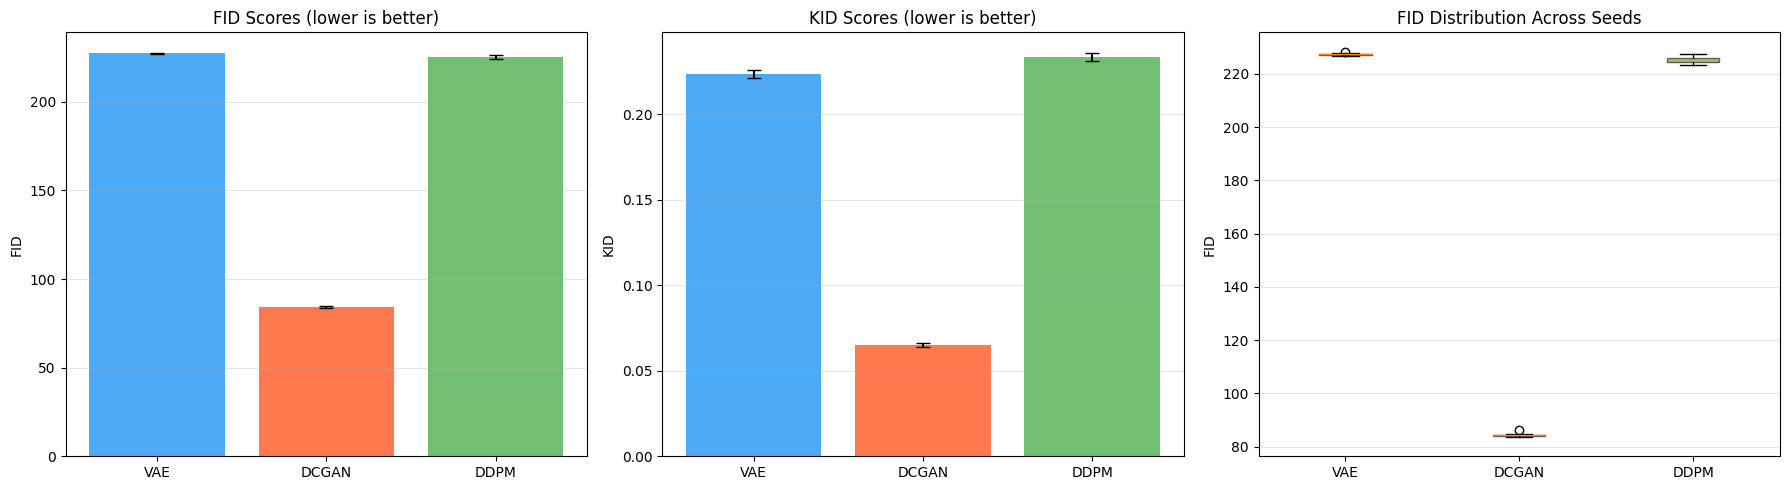

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. FID bar chart with error bars
model_names = list(all_results.keys())
fid_means = [all_results[m]['fid_mean'] for m in model_names]
fid_stds = [all_results[m]['fid_std'] for m in model_names]
colors = ['#2196F3', '#FF5722', '#4CAF50']

axes[0].bar(model_names, fid_means, yerr=fid_stds, capsize=5, color=colors, alpha=0.8)
axes[0].set_title('FID Scores (lower is better)')
axes[0].set_ylabel('FID')
axes[0].grid(True, axis='y', alpha=0.3)

# 2. KID bar chart with error bars
kid_means = [all_results[m]['kid_mean'] for m in model_names]
kid_stds = [all_results[m]['kid_std'] for m in model_names]

axes[1].bar(model_names, kid_means, yerr=kid_stds, capsize=5, color=colors, alpha=0.8)
axes[1].set_title('KID Scores (lower is better)')
axes[1].set_ylabel('KID')
axes[1].grid(True, axis='y', alpha=0.3)

# 3. FID distribution across seeds (box plot)
fid_data = [all_results[m]['fid_all'] for m in model_names]
bp = axes[2].boxplot(fid_data, labels=model_names, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[2].set_title('FID Distribution Across Seeds')
axes[2].set_ylabel('FID')
axes[2].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


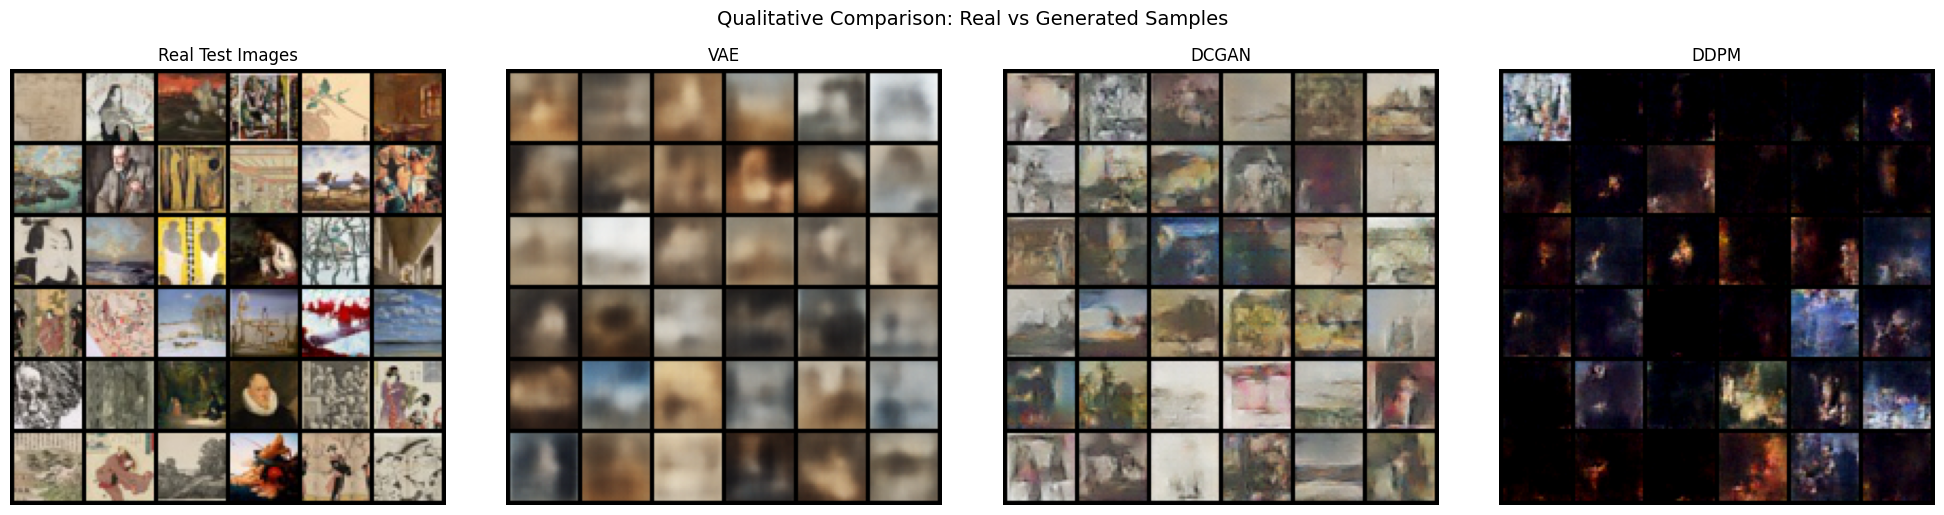

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Real samples
real_grid = make_grid(real_images[:36].cpu(), nrow=6, padding=2)
axes[0].imshow(real_grid.permute(1, 2, 0).numpy())
axes[0].set_title('Real Test Images')
axes[0].axis('off')

# VAE samples
vae_model.eval()
vae_vis = vae_model.sample(36, device)
vae_grid = make_grid(vae_vis.cpu(), nrow=6, padding=2)
axes[1].imshow(vae_grid.permute(1, 2, 0).numpy())
axes[1].set_title('VAE')
axes[1].axis('off')

# DCGAN samples
gen_model.eval()
gan_vis = gen_model.sample(36, device)
gan_grid = make_grid(gan_vis.cpu(), nrow=6, padding=2)
axes[2].imshow(gan_grid.permute(1, 2, 0).numpy())
axes[2].set_title('DCGAN')
axes[2].axis('off')

# DDPM samples
ddpm_vis = ddpm_sample(ddpm_model, schedule, 36, device=device)
ddpm_grid = make_grid(ddpm_vis.cpu(), nrow=6, padding=2)
axes[3].imshow(ddpm_grid.permute(1, 2, 0).numpy())
axes[3].set_title('DDPM')
axes[3].axis('off')

plt.suptitle('Qualitative Comparison: Real vs Generated Samples', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Best model from development phase: DCGAN
Retraining DCGAN on full 50K dataset for 50 epochs...

  Epoch [1/50] D_loss: 0.4845 G_loss: 4.3638
  Epoch [2/50] D_loss: 0.5387 G_loss: 3.6341
  Epoch [3/50] D_loss: 0.6330 G_loss: 2.8636
  Epoch [4/50] D_loss: 0.6703 G_loss: 2.6345
  Epoch [5/50] D_loss: 0.7379 G_loss: 2.5955
  Epoch [6/50] D_loss: 0.7063 G_loss: 2.5393
  Epoch [7/50] D_loss: 0.6833 G_loss: 2.5081
  Epoch [8/50] D_loss: 0.6276 G_loss: 2.6366
  Epoch [9/50] D_loss: 0.6480 G_loss: 2.6372
  Epoch [10/50] D_loss: 0.6303 G_loss: 2.7735
  Epoch [11/50] D_loss: 0.6241 G_loss: 2.7356
  Epoch [12/50] D_loss: 0.6316 G_loss: 2.7624
  Epoch [13/50] D_loss: 0.5939 G_loss: 2.8441
  Epoch [14/50] D_loss: 0.5587 G_loss: 2.9533
  Epoch [15/50] D_loss: 0.5300 G_loss: 3.0691
  Epoch [16/50] D_loss: 0.4420 G_loss: 3.1897
  Epoch [17/50] D_loss: 0.4616 G_loss: 3.3619
  Epoch [18/50] D_loss: 0.4485 G_loss: 3.4491
  Epoch [19/50] D_loss: 0.3815 G_loss: 3.5850
  Epoch [20/50] D_loss: 0.3825 G_loss: 

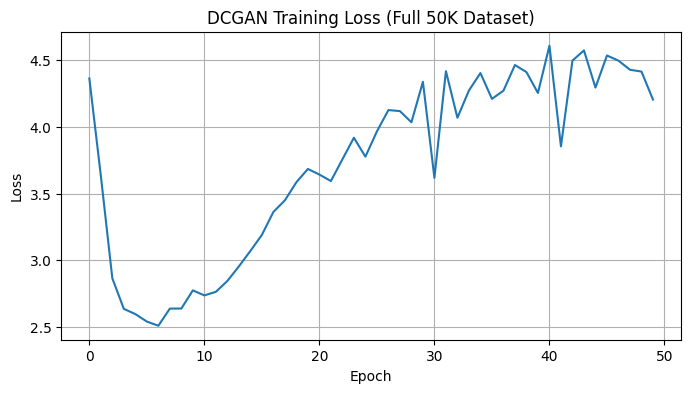

In [ ]:
FINAL_EPOCHS = 50  
FINAL_N_EVAL = 5000  
FINAL_NUM_SEEDS = 10  

print(f"Best model from development phase: {best_model}")
print(f"Retraining {best_model} on full 50K dataset for {FINAL_EPOCHS} epochs...\n")

if best_model == 'VAE':
    final_model = VAE(LATENT_DIM).to(device)
    final_optimizer = optim.Adam(final_model.parameters(), lr=VAE_LR)
    final_losses = []

    for epoch in range(FINAL_EPOCHS):
        final_model.train()
        epoch_loss = 0.0
        for x, _ in train_loader_full:
            x = x.to(device)
            recon, mu, logvar = final_model(x)
            loss, _, _ = vae_loss(recon, x, mu, logvar)
            final_optimizer.zero_grad()
            loss.backward()
            final_optimizer.step()
            epoch_loss += loss.item()
        avg = epoch_loss / len(train_loader_full)
        final_losses.append(avg)
        print(f"  Epoch [{epoch+1}/{FINAL_EPOCHS}] Loss: {avg:.4f}")

    def final_gen_func(seed):
        return generate_vae_samples(final_model, FINAL_N_EVAL, seed, device)

elif best_model == 'DCGAN':
    final_gen = DCGANGenerator(Z_DIM).to(device)
    final_disc = DCGANDiscriminator().to(device)
    final_gen.apply(weights_init)
    final_disc.apply(weights_init)
    final_criterion = nn.BCELoss()
    final_opt_gen = optim.Adam(final_gen.parameters(), lr=GAN_LR, betas=(GAN_BETA1, 0.999))
    final_opt_disc = optim.Adam(final_disc.parameters(), lr=GAN_LR, betas=(GAN_BETA1, 0.999))
    final_losses = []

    for epoch in range(FINAL_EPOCHS):
        final_gen.train()
        final_disc.train()
        eg, ed = 0.0, 0.0
        for x_real, _ in train_loader_full:
            bs = x_real.size(0)
            x_real = x_real.to(device) * 2.0 - 1.0
            rl = torch.ones(bs, device=device)
            fl = torch.zeros(bs, device=device)

            final_disc.zero_grad()
            loss_dr = final_criterion(final_disc(x_real), rl)
            z = torch.randn(bs, Z_DIM, device=device)
            xf = final_gen(z)
            loss_df = final_criterion(final_disc(xf.detach()), fl)
            (loss_dr + loss_df).backward()
            final_opt_disc.step()

            final_gen.zero_grad()
            loss_g = final_criterion(final_disc(xf), rl)
            loss_g.backward()
            final_opt_gen.step()
            eg += loss_g.item()
            ed += (loss_dr.item() + loss_df.item())
        avg_g = eg / len(train_loader_full)
        avg_d = ed / len(train_loader_full)
        final_losses.append(avg_g)
        print(f"  Epoch [{epoch+1}/{FINAL_EPOCHS}] D_loss: {avg_d:.4f} G_loss: {avg_g:.4f}")

    final_model = final_gen
    def final_gen_func(seed):
        return generate_gan_samples(final_model, FINAL_N_EVAL, seed, device)

else:  # DDPM
    final_model = SimpleUNet(in_ch=3, base_ch=64, time_dim=256).to(device)
    final_schedule = DDPMSchedule(T=T_STEPS, device=device)
    final_optimizer = optim.Adam(final_model.parameters(), lr=DDPM_LR)
    final_losses = []

    for epoch in range(FINAL_EPOCHS):
        final_model.train()
        epoch_loss = 0.0
        for x, _ in train_loader_full:
            x = x.to(device) * 2.0 - 1.0
            t = torch.randint(0, T_STEPS, (x.size(0),), device=device)
            x_noisy, noise = final_schedule.q_sample(x, t)
            noise_pred = final_model(x_noisy, t)
            loss = F.mse_loss(noise_pred, noise)
            final_optimizer.zero_grad()
            loss.backward()
            final_optimizer.step()
            epoch_loss += loss.item()
        avg = epoch_loss / len(train_loader_full)
        final_losses.append(avg)
        print(f"  Epoch [{epoch+1}/{FINAL_EPOCHS}] Loss: {avg:.4f}")

    def final_gen_func(seed):
        return generate_ddpm_samples(final_model, final_schedule, FINAL_N_EVAL, seed, device)

print(f"\n{best_model} retrained on full dataset. Running final evaluation...\n")

final_seeds = list(range(42, 42 + FINAL_NUM_SEEDS))

real_images_final = collect_real_images(test_loader, FINAL_N_EVAL)
real_features_final = feat_extractor.extract_features(real_images_final)

final_results = evaluate_model(
    gen_func=final_gen_func,
    real_features=real_features_final,
    feat_extractor=feat_extractor,
    seeds=final_seeds,
    n_eval=FINAL_N_EVAL,
)

print("\n" + "=" * 60)
print(f"FINAL RESULTS — {best_model} retrained on full 50K dataset")
print("=" * 60)
print(f"FID: {final_results['fid_mean']:.2f} ± {final_results['fid_std']:.2f}")
print(f"KID: {final_results['kid_mean']:.6f} ± {final_results['kid_std']:.6f}")

dev_result = all_results[best_model]
print(f"\nComparison with 20% subset:")
print(f"  Dev  FID: {dev_result['fid_mean']:.2f} ± {dev_result['fid_std']:.2f}")
print(f"  Full FID: {final_results['fid_mean']:.2f} ± {final_results['fid_std']:.2f}")

plt.figure(figsize=(8, 4))
plt.plot(final_losses)
plt.title(f'{best_model} Training Loss (Full 50K Dataset)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()